# Reverse-Engineering WHOOP's Sleep Performance Score

**Context:** WHOOP's Sleep Performance score is officially built from four components:
*Hours vs. Needed, Sleep Efficiency, Sleep Consistency,* and *Sleep Stress*.

This notebook asks a simple question: **using the four documented components, how closely
can a linear model reconstruct WHOOP's own black-box score?**

This is a single-subject (n=1) case study — not statistically generalizable — but it doubles
as a small working prototype of the kind of load/recovery modeling pipeline used in sports
science (the same broad idea behind player readiness monitoring in football).

## Data

Source: WHOOP data export (`physiological_cycles.csv`), covering all four official Sleep
Performance components for 93 nights (9 Apr - 11 Jul 2026). One row = one WHOOP sleep cycle.

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error
from statsmodels.stats.power import TTestIndPower

In [74]:
df = pd.read_csv('data/whoop_sleep_data.csv', parse_dates=['Cycle start time'])
df.head()

,Cycle start time,Recovery score %,Sleep performance %,hours_vs_needed,Sleep efficiency %,Sleep consistency %,sleep_stress
0,2026-04-09 23:24:36,42.0,86.0,86.301370,95.0,NaN,0
1,2026-04-10 23:10:03,48.0,89.0,90.448343,93.0,NaN,0
2,2026-04-11 22:52:29,48.0,92.0,87.985213,93.0,92.0,0
3,2026-04-12 22:33:53,55.0,93.0,89.776952,94.0,91.0,0
4,2026-04-13 22:45:24,61.0,100.0,99.607073,92.0,90.0,0


In [75]:
df.isna().sum()

,0
Cycle start time,0
Recovery score %,0
Sleep performance %,0
hours_vs_needed,0
Sleep efficiency %,0
Sleep consistency %,2
sleep_stress,0


In [76]:
df = df.dropna(subset=['Sleep consistency %']).reset_index(drop=True)

### Data cleaning

`Sleep consistency %` needs a 4-day rolling history to be calculated, so it's missing for
the first 2 nights of the tracking period (9-10 April). Since every model in this notebook
uses all four components together, these 2 nights are dropped rather than imputed — with
only 93 nights total, guessing a value for a missing metric felt riskier than simply losing
2 observations. This leaves 91 clean nights for analysis.

In [77]:
features = ['hours_vs_needed', 'Sleep efficiency %', 'Sleep consistency %', 'sleep_stress']
target = 'Sleep performance %'

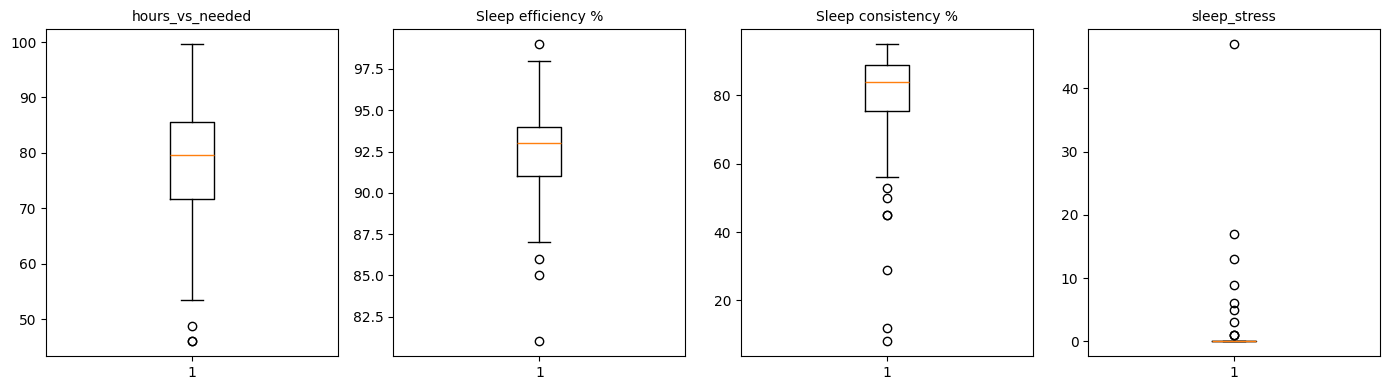

In [78]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, features):
    ax.boxplot(df[col], vert=True)
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.show()

`sleep_stress` is heavily right-skewed — the vast majority of nights sit at 0, with a long
tail up to 47 on the worst night. `Sleep efficiency %` is the tightest, most symmetric
distribution of the four, which foreshadows the range-restriction issue explored later.
`hours_vs_needed` and `Sleep consistency %` both show wider, more usable spread.

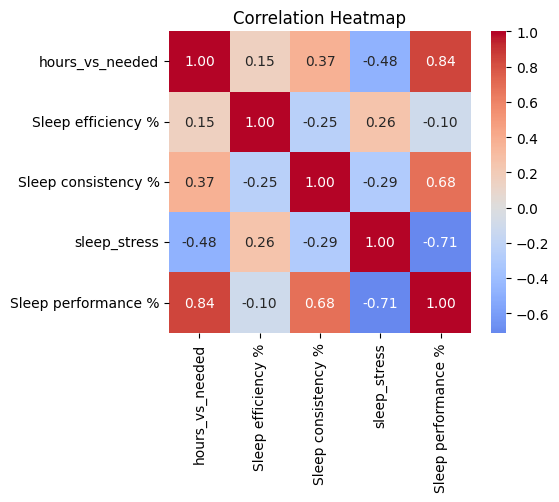

In [79]:
corr_cols = features + [target]
corr = df[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

Sleep efficiency is the odd one out here — visibly weaker correlation with Sleep Performance
than the other three components. None of the four predictors are strongly correlated *with
each other*, which is good news for the regression: it means each one is contributing
independent information rather than duplicating another (confirmed later by the low
condition number, 2.31, in the OLS output).

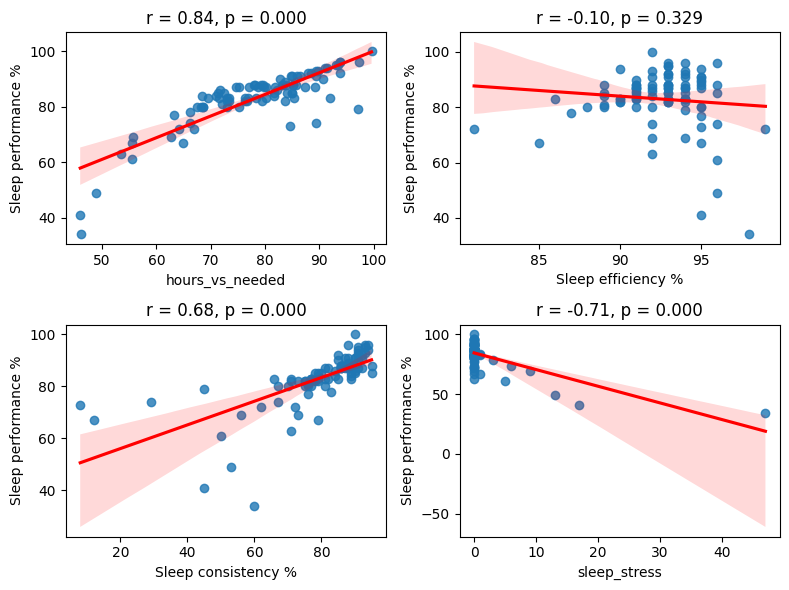

In [80]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

for ax, f in zip(axes.flat, features):
    sns.regplot(x=df[f], y=df[target], ax=ax, line_kws={'color': 'red'})
    r, p = stats.pearsonr(df[target], df[f])
    ax.set_title(f"r = {r:.2f}, p = {p:.3f}")

plt.tight_layout()

`hours_vs_needed` and `Sleep consistency %` both show a clear, roughly linear upward trend.
`sleep_stress` trends downward, but the relationship is driven largely by the handful of
nights with any measurable stress — most points sit stacked at 0. `Sleep efficiency %`
is the outlier: the point cloud is essentially flat, with no visible trend line to speak of.

In [81]:
X = df[features].copy()
y = df[target]

X_std = (X - X.mean()) / X.std()
X_std = sm.add_constant(X_std)

model = sm.OLS(y, X_std).fit()
print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     Sleep performance %   R-squared:                       0.955
Model:                             OLS   Adj. R-squared:                  0.953
Method:                  Least Squares   F-statistic:                     453.9
Date:                 Sat, 11 Jul 2026   Prob (F-statistic):           6.40e-57
Time:                         10:57:03   Log-Likelihood:                -203.93
No. Observations:                   91   AIC:                             417.9
Df Residuals:                       86   BIC:                             430.4
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  8

In [82]:
X_arr = df[features].values
y_arr = df[target].values

loo = LeaveOneOut()
preds = cross_val_predict(LinearRegression(), X_arr, y_arr, cv=loo)

r2_oos = r2_score(y_arr, preds)
mae_oos = mean_absolute_error(y_arr, preds)
baseline_mae = mean_absolute_error(y_arr, [y_arr.mean()] * len(y_arr))

print(f"Out-of-sample R^2 (LOOCV):  {r2_oos:.3f}")
print(f"Out-of-sample MAE (LOOCV): {mae_oos:.2f} points")
print(f"Baseline MAE (predict the mean): {baseline_mae:.2f} points")

Out-of-sample R^2 (LOOCV):  0.922
Out-of-sample MAE (LOOCV): 1.91 points
Baseline MAE (predict the mean): 6.97 points


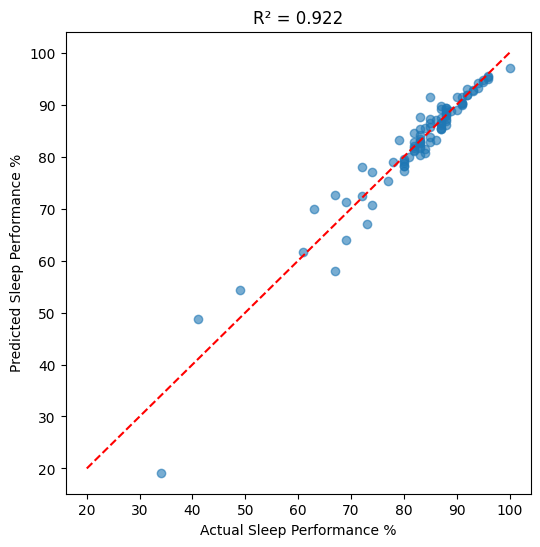

In [83]:
plt.figure(figsize=(6, 6))
plt.scatter(y_arr, preds, alpha=0.6)
plt.plot([20, 100], [20, 100], 'r--')
plt.xlabel('Actual Sleep Performance %')
plt.ylabel('Predicted Sleep Performance %')
plt.title(f'R² = {r2_oos:.3f}')
plt.show()

Predictions are tight and reliable in the 80-100% range, where most of the data lives.
The few low-Sleep-Performance nights (all from illness/travel-disrupted sleep) show more
scatter around the diagonal — expected, since the model has fewer examples to learn from
in that region.

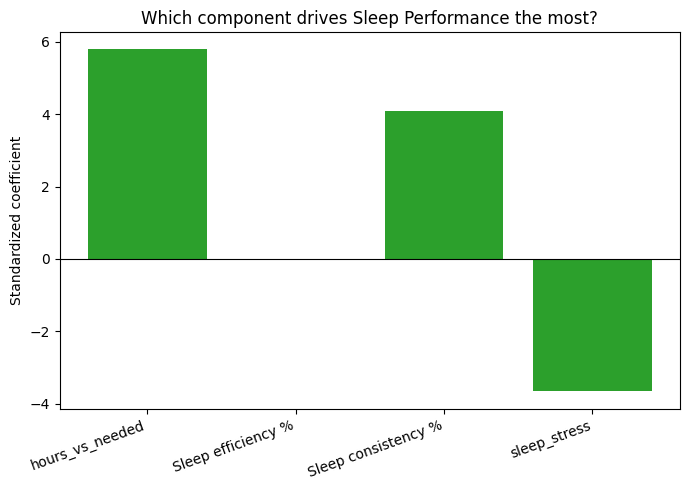

In [84]:
coefs = model.params.drop('const')
pvals = model.pvalues.drop('const')
colors = ['tab:green' if p < 0.05 else 'lightgray' for p in pvals]

plt.figure(figsize=(7, 5))
plt.bar(features, coefs.values, color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('Standardized coefficient')
plt.title('Which component drives Sleep Performance the most?')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()

`hours_vs_needed` is the single strongest lever, followed closely by `Sleep consistency %`.
`sleep_stress` has a meaningful negative effect. `Sleep efficiency %`'s bar is essentially
invisible — visual confirmation of the p=0.899 result above, and the starting point for
the deeper look in the next section.

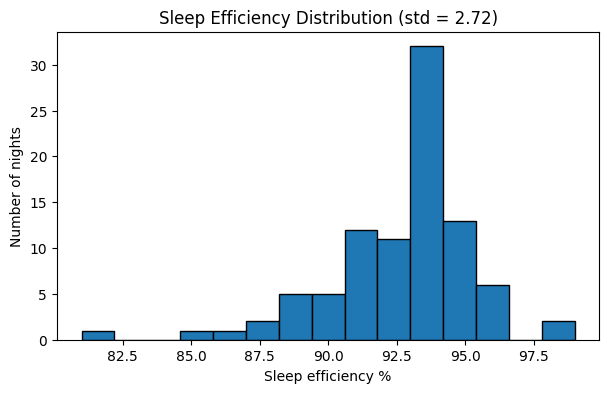

In [85]:
plt.figure(figsize=(7, 4))
plt.hist(df['Sleep efficiency %'], bins=15, edgecolor='black')
plt.xlabel('Sleep efficiency %')
plt.ylabel('Number of nights')
plt.title(f"Sleep Efficiency Distribution (std = {df['Sleep efficiency %'].std():.2f})")
plt.show()

This confirms the restriction-of-range hypothesis directly: nights cluster tightly between
91-96% efficiency (std = 2.72), with almost nothing below 85%. There simply isn't enough
low-efficiency data in this window for the metric to show its effect statistically —
quantified precisely by the power analysis below.

### Is there a threshold effect instead of a linear one?

A linear model might miss a "ceiling effect" — efficiency could matter, but only once it
drops below some critical point, with no meaningful difference above it. Splitting nights
into low (< 90%) and high (≥ 90%) efficiency groups tests this directly.

In [86]:
threshold = 90
df['low_efficiency'] = df['Sleep efficiency %'] < threshold

print(df.groupby('low_efficiency')['Sleep performance %'].agg(['mean', 'std', 'count']))

low = df[df['low_efficiency']]['Sleep performance %']
high = df[~df['low_efficiency']]['Sleep performance %']
t, p = stats.ttest_ind(low, high, equal_var=False)
print(f"\nt-test: t={t:.2f}, p={p:.4f}")

                    mean        std  count
low_efficiency                            
False           83.37037  11.152852     81
True            79.80000   6.250333     10

t-test: t=-1.53, p=0.1441


The difference is in the expected direction — low-efficiency nights score 3.57 points lower
on average (79.8 vs. 83.4) — but with only 10 low-efficiency nights, the test doesn't reach
significance (p = 0.144). Whether this is a real, small effect that this sample is too small
to detect, or genuinely no effect, can't be resolved with a group comparison alone. The power
analysis below quantifies exactly how much data would be needed to tell the difference.

### How much data would it take to know for sure?

Rather than guessing, this computes the effect size actually observed above (Cohen's d) and
asks: given that effect size, how many low-efficiency nights would be needed to detect it
reliably (80% statistical power, the conventional threshold)?

In [87]:
# Observed effect size (Cohen's d)
mean_diff = high.mean() - low.mean()
pooled_std = np.sqrt(((len(low)-1)*low.std()**2 + (len(high)-1)*high.std()**2) / (len(low)+len(high)-2))
cohens_d = mean_diff / pooled_std

print(f"Observed difference: {mean_diff:.2f} points")
print(f"Cohen's d: {cohens_d:.3f}")

# Sample size required per group to detect this effect size with 80% power
analysis = TTestIndPower()
n_required = analysis.solve_power(effect_size=cohens_d, alpha=0.05, power=0.8, ratio=1.0)

print(f"\nNights required per group for 80% power: {n_required:.0f}")
print(f"Low-efficiency nights available: {len(low)}")

Observed difference: 3.57 points
Cohen's d: 0.332

Nights required per group for 80% power: 144
Low-efficiency nights available: 10


The answer: **144 nights per group** — this dataset has 10. Cohen's d = 0.332 indicates a
small-to-moderate real effect, not noise, but this sample is only about 7% of the size
needed to confirm it statistically. This reframes the earlier null result: sleep efficiency
is very likely not "irrelevant" — it's under-powered here, and the dataset itself explains
why (see the histogram above).

## Summary & Limitations

- Reconstructed WHOOP's Sleep Performance score from its 4 documented components:
  **R² = 0.955 in-sample, 0.922 out-of-sample (LOOCV)**.
  logged component (Sleep Stress): **R² = 0.955 in-sample, 0.922 out-of-sample (LOOCV)**.
- `hours_vs_needed` and `Sleep consistency %` (positive) and `sleep_stress` (negative) are
  the significant drivers.
- `Sleep efficiency %` showed no significant linear effect (p = 0.899) — but a deeper look
  suggests this isn't because efficiency doesn't matter. A threshold test (efficiency < 90%)
  found a difference in the expected direction (3.57 points, Cohen's d = 0.332), and a power
  analysis showed that detecting this effect reliably would require ~144 low-efficiency nights
  per group — this dataset had only 10. The metric is likely real but statistically
  under-powered here, not irrelevant.

**Limitations:**
- n=1 (single subject, 91 nights) — not statistically generalizable to other people.
- Sleep efficiency stayed in a narrow, high range (91–96%) for most nights — a classic
  restriction-of-range problem that limited what this analysis could detect.

Built as a small working prototype of the wearable-data modeling pipeline relevant to
fatigue/load monitoring in sports science — the long-term goal being to apply the same
approach to real athlete data.

**Author** : Alper Karayaz — Data Science & Engineering, Politecnico di Torino